# HW06 – Деревья решений и ансамбли

Домашнее задание к семинару 06: сравнение моделей недели 6 (дерево решений, Random Forest, Boosting) в честном ML-эксперименте.

## Цель

- Закрепить понимание деревьев решений и контроля их сложности
- Практически освоить ансамбли: bagging, Random Forest, boosting
- Провести честный ML-эксперимент: фиксированный train/test, CV на train для подбора гиперпараметров, единые метрики, фиксация артефактов
- Интерпретировать лучшую модель через permutation importance

## Датасет

Выбран: `S06-hw-dataset-01.csv` – бинарная классификация с умеренным дисбалансом классов.

## 0. Настройки, импорты, пути для артефактов

Фиксируем `RANDOM_STATE` для воспроизводимости и создаём папку `artifacts/` для сохранения результатов эксперимента.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
)

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

import joblib

# Фиксация случайности для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Создание папки для артефактов
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = ARTIFACTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts dir:", ARTIFACTS_DIR.resolve())
print("Figures dir:", FIGURES_DIR.resolve())

Artifacts dir: C:\Users\Гошанский\PycharmProjects\mirea-aie\homeworks\HW06\artifacts
Figures dir: C:\Users\Гошанский\PycharmProjects\mirea-aie\homeworks\HW06\artifacts\figures


## Вспомогательные функции

Функции для единообразной оценки моделей и сохранения артефактов.

In [2]:
def compute_metrics(y_true, y_pred, y_proba=None) -> dict:
    """Вычисляет метрики качества модели."""
    m = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
    }
    if y_proba is not None:
        try:
            m["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            m["roc_auc"] = None
    else:
        m["roc_auc"] = None
    return m

def evaluate_on_test(model, X_test, y_test, label: str) -> dict:
    """Оценивает модель на тестовой выборке."""
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, pred, proba)
    metrics["model"] = label
    return metrics

def save_json(obj: dict, path: Path):
    """Сохраняет словарь в JSON файл."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

print("Вспомогательные функции определены")

Вспомогательные функции определены


## 1. Загрузка данных и первичный анализ

In [3]:
# Загрузка датасета
df = pd.read_csv("S06-hw-dataset-01.csv")

print("Размер датасета:", df.shape)
print("\nПервые строки:")
df.head()

Размер датасета: (12000, 30)

Первые строки:


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,...,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,...,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,...,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,...,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,...,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0


In [4]:
# Базовая информация о данных
print("Информация о данных:")
df.info()
print("\n" + "="*50)
print("\nБазовые статистики:")
df.describe()

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null

,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,0.013705,-0.005278,-0.002357,0.038404,-0.006301,-0.865297,-0.702877,-0.290694,-0.008154,...,-0.323083,-1.314833,0.319798,-0.002742,0.027459,0.988750,1.990167,1.506833,36.083833,0.323417
std,3464.24595,2.096534,3.544498,1.004417,2.087318,1.007329,3.888966,1.989513,3.455981,0.996677,...,2.167066,3.731384,2.223649,0.996454,1.882359,0.815687,1.411643,1.121558,25.061218,0.467800
min,1.00000,-8.155181,-14.605579,-4.374043,-7.753301,-3.999332,-15.238402,-7.377252,-13.853627,-3.794637,...,-8.371050,-14.249204,-8.638879,-3.532093,-7.923990,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,-1.423844,-2.303772,-0.685618,-1.374579,-0.676552,-3.532054,-2.064888,-2.597019,-0.683959,...,-1.808969,-3.863063,-1.097700,-0.676150,-1.110822,0.000000,1.000000,0.000000,17.000000,0.000000
50%,6000.50000,-0.047565,0.053348,-0.009186,0.038766,-0.003728,-1.092517,-0.795907,-0.208245,-0.020883,...,-0.383940,-1.393400,0.431804,0.006297,0.279689,1.000000,2.000000,2.000000,30.000000,0.000000
75%,9000.25000,1.422676,2.335937,0.671441,1.484417,0.669269,1.526389,0.522625,2.093169,0.666959,...,1.125140,1.116111,1.853491,0.657478,1.363896,2.000000,3.000000,3.000000,49.000000,1.000000
max,12000.00000,8.610863,16.299709,3.651692,7.571965,4.562115,16.223054,8.006444,13.030011,3.976868,...,7.957847,15.937281,8.102095,3.707905,7.549514,2.000000,4.000000,3.000000,120.000000,1.000000


In [5]:
# Проверка пропусков
print("Пропуски в данных:")
print(df.isnull().sum().sum(), "пропусков всего")
print("\nПропуски по столбцам:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет")

Пропуски в данных:
0 пропусков всего

Пропуски по столбцам:
Пропусков нет


Распределение целевой переменной 'target':
target
0    0.676583
1    0.323417
Name: proportion, dtype: float64

Абсолютные значения:
target
0    8119
1    3881
Name: count, dtype: int64


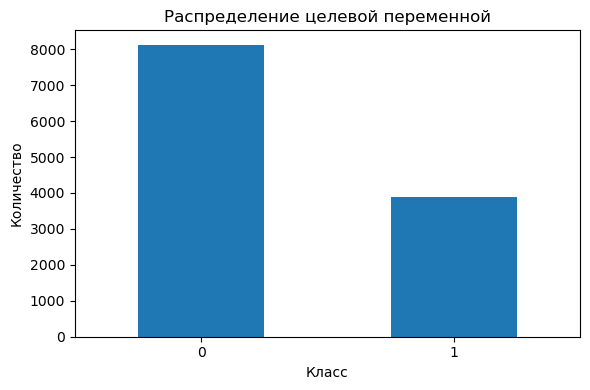

In [6]:
# Распределение целевой переменной
print("Распределение целевой переменной 'target':")
target_dist = df['target'].value_counts(normalize=True)
print(target_dist)
print("\nАбсолютные значения:")
print(df['target'].value_counts())

# Визуализация
plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar')
plt.title('Распределение целевой переменной')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Определение признаков и целевой переменной
# Исключаем 'id' и 'target' из признаков
X = df.drop(columns=['id', 'target'])
y = df['target']

print(f"Признаков: {X.shape[1]}")
print(f"Объектов: {X.shape[0]}")
print(f"\nТипы признаков:")
print(X.dtypes.value_counts())

Признаков: 28
Объектов: 12000

Типы признаков:
float64    24
int64       4
Name: count, dtype: int64


## 2. Train/Test-сплит и воспроизводимость

**Важность фиксированного seed и стратификации:**

- `random_state` фиксирует случайность разбиения, что делает эксперимент воспроизводимым
- `stratify=y` сохраняет пропорции классов в train и test, что важно для корректной оценки, особенно при дисбалансе классов
- Без фиксации seed результаты могут варьироваться, что затрудняет сравнение моделей

In [8]:
# Разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {X_train.shape[0]} объектов, {X_train.shape[1]} признаков")
print(f"Test: {X_test.shape[0]} объектов, {X_test.shape[1]} признаков")
print(f"\nРаспределение классов в train:")
print(y_train.value_counts(normalize=True))
print(f"\nРаспределение классов в test:")
print(y_test.value_counts(normalize=True))

Train: 9000 объектов, 28 признаков
Test: 3000 объектов, 28 признаков

Распределение классов в train:
target
0    0.676556
1    0.323444
Name: proportion, dtype: float64

Распределение классов в test:
target
0    0.676667
1    0.323333
Name: proportion, dtype: float64


## 3. Baseline'ы

Baseline'ы нужны как "точка отсчёта". Если модель недели 6 не обгоняет baseline, то либо она не подходит под задачу, либо неправильно настроена.

1. **DummyClassifier** – простейшая нижняя планка (угадываем самый частый класс)
2. **LogisticRegression** – сильный baseline из прошлой недели (линейная модель + нормировка признаков)

In [9]:
# Подготовка контейнеров для результатов
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
best_models = {}  # label -> fitted best estimator
search_summaries = {}  # label -> краткая инфа о подборе

# 3.1 Dummy baseline
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
results.append(evaluate_on_test(dummy, X_test, y_test, "Dummy(most_frequent)"))
best_models["Dummy(most_frequent)"] = dummy

print("Dummy baseline обучен")
pd.DataFrame([results[-1]])

Dummy baseline обучен


,accuracy,f1,roc_auc,model
0,0.676667,0.0,0.5,Dummy(most_frequent)


In [11]:
# 3.2 LogisticRegression baseline (с подбором гиперпараметра C)
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=4000, random_state=RANDOM_STATE))
])

lr_grid = {
    "lr__C": [0.1, 1.0, 10.0],
    "lr__penalty": ["l2"],
    "lr__solver": ["lbfgs"],
}

lr_search = GridSearchCV(
    lr, lr_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)
lr_search.fit(X_train, y_train)

best_lr = lr_search.best_estimator_
best_models["LogReg(scaled)"] = best_lr

search_summaries["LogReg(scaled)"] = {
    "best_params": lr_search.best_params_,
    "best_cv_roc_auc": float(lr_search.best_score_),
}

results.append(evaluate_on_test(best_lr, X_test, y_test, "LogReg(scaled)"))

print("LogisticRegression baseline обучен")
print("Лучшие параметры:", lr_search.best_params_)
print("CV ROC-AUC:", lr_search.best_score_)
pd.DataFrame([results[-1]])

LogisticRegression baseline обучен
Лучшие параметры: {'lr__C': 10.0, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
CV ROC-AUC: 0.8822238806908922


,accuracy,f1,roc_auc,model
0,0.829667,0.714685,0.878905,LogReg(scaled)


## 4. Модели недели 6

Сравниваем три семейства моделей:

- **Decision Tree** – простая нелинейность, быстро обучается, легко переобучается без ограничений
- **Random Forest** – ансамбль деревьев (bagging), обычно устойчивее и сильнее одного дерева
- **HistGradientBoosting** – градиентный бустинг (часто даёт высокое качество на табличных данных)

**Протокол подбора:**
- Гиперпараметры подбираем через `GridSearchCV` **только на train**
- Метрика для подбора: `roc_auc`
- Тест используем **ровно один раз** – для финальной честной оценки лучших моделей

In [12]:
# Единая функция для подбора гиперпараметров через GridSearchCV
def run_search(label: str, estimator, param_grid: dict):
    """Выполняет GridSearchCV и сохраняет результаты."""
    search = GridSearchCV(
        estimator,
        param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )
    search.fit(X_train, y_train)

    best = search.best_estimator_
    best_models[label] = best
    search_summaries[label] = {
        "best_params": search.best_params_,
        "best_cv_roc_auc": float(search.best_score_),
    }
    results.append(evaluate_on_test(best, X_test, y_test, label))
    return search

print("Функция run_search определена")

Функция run_search определена


### 4.1 Decision Tree

Контроль сложности через:
- `max_depth` – максимальная глубина дерева
- `min_samples_leaf` – минимальное количество образцов в листе
- `ccp_alpha` – параметр cost-complexity pruning (штраф за сложность)

In [13]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

dt_grid = {
    "max_depth": [None, 3, 5, 8, 10],
    "min_samples_leaf": [1, 5, 10, 20],
    "ccp_alpha": [0.0, 0.001, 0.005, 0.01],
}

print("Подбор параметров для Decision Tree...")
dt_search = run_search("DecisionTree", dt, dt_grid)
print("Готово!")
print("Лучшие параметры:", dt_search.best_params_)
print("CV ROC-AUC:", dt_search.best_score_)
pd.DataFrame([results[-1]])

Подбор параметров для Decision Tree...
Готово!
Лучшие параметры: {'ccp_alpha': 0.0, 'max_depth': 10, 'min_samples_leaf': 20}
CV ROC-AUC: 0.9116379696974597


,accuracy,f1,roc_auc,model
0,0.868333,0.791996,0.911945,DecisionTree


### 4.2 Random Forest

Ансамбль деревьев (bagging):
- `n_estimators` – количество деревьев (снижает дисперсию)
- `max_features` – добавляет разнообразие деревьев (важно для ансамблей)
- `max_depth`, `min_samples_leaf` – ограничения для контроля переобучения

In [14]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    oob_score=False
)

rf_grid = {
    "max_depth": [None, 6, 10, 15],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.5, "log2"],
}

print("Подбор параметров для Random Forest...")
rf_search = run_search("RandomForest", rf, rf_grid)
print("Готово!")
print("Лучшие параметры:", rf_search.best_params_)
print("CV ROC-AUC:", rf_search.best_score_)
pd.DataFrame([results[-1]])

Подбор параметров для Random Forest...
Готово!
Лучшие параметры: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1}
CV ROC-AUC: 0.9675772651089527


,accuracy,f1,roc_auc,model
0,0.933,0.890701,0.970235,RandomForest


### 4.3 HistGradientBoosting

Градиентный бустинг по гистограммам (быстро и часто качественно):
- `learning_rate` – шаг обучения (меньше → аккуратнее, часто нужно больше итераций)
- `max_depth` / `max_leaf_nodes` – сложность базовых деревьев
- `early_stopping=True` включает остановку по внутренней валидации

In [15]:
# HistGradientBoosting
hgb = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    early_stopping=True,
    max_iter=200
)

hgb_grid = {
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 5, None],
    "max_leaf_nodes": [15, 31, 63],
}

print("Подбор параметров для HistGradientBoosting...")
hgb_search = run_search("HistGradientBoosting", hgb, hgb_grid)
print("Готово!")
print("Лучшие параметры:", hgb_search.best_params_)
print("CV ROC-AUC:", hgb_search.best_score_)
pd.DataFrame([results[-1]])

Подбор параметров для HistGradientBoosting...
Готово!
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': None, 'max_leaf_nodes': 63}
CV ROC-AUC: 0.9721417717189265


,accuracy,f1,roc_auc,model
0,0.936667,0.898721,0.974218,HistGradientBoosting


## 5. Сводка результатов (test)

Соберём все результаты в таблицу и отсортируем модели по ROC-AUC (если он посчитан), иначе по accuracy.

**Метрики:**
- **accuracy**: доля верных ответов (может быть "обманчивой" при сильном дисбалансе классов)
- **F1**: баланс точности и полноты для положительного класса
- **ROC-AUC**: качество ранжирования вероятностей (чем ближе к 1.0, тем лучше)

In [16]:
# Сводка результатов в таблицу
df_results = pd.DataFrame(results)

# Сортировка: roc_auc (если есть) иначе accuracy
df_sorted = df_results.copy()
df_sorted["roc_auc_sort"] = df_sorted["roc_auc"].fillna(-1.0)
df_sorted = df_sorted.sort_values(["roc_auc_sort", "accuracy"], ascending=False).drop(columns=["roc_auc_sort"])

print("Результаты всех моделей на тесте:")
df_sorted

Результаты всех моделей на тесте:


,accuracy,f1,roc_auc,model
5,0.936667,0.898721,0.974218,HistGradientBoosting
4,0.933000,0.890701,0.970235,RandomForest
3,0.868333,0.791996,0.911945,DecisionTree
1,0.829667,0.714685,0.878905,LogReg(scaled)
2,0.829667,0.714685,0.878905,LogReg(scaled)
0,0.676667,0.000000,0.500000,Dummy(most_frequent)


In [17]:
# Сохранение метрик в artifacts/
metrics_path = ARTIFACTS_DIR / "metrics_test.json"
search_path = ARTIFACTS_DIR / "search_summaries.json"

save_json({"results": df_sorted.to_dict(orient="records")}, metrics_path)
save_json(search_summaries, search_path)

print("Saved:", metrics_path)
print("Saved:", search_path)

Saved: artifacts\metrics_test.json
Saved: artifacts\search_summaries.json


## 6. Лучшая модель: диагностика на тесте

Выберем лучшую модель (по ROC-AUC) и проведём диагностику:
- **Confusion matrix** – показывает, где именно модель ошибается (FP/FN)
- **ROC-кривая** – показывает качество ранжирования вероятностей по всем порогам

In [18]:
# Выбор лучшей модели
best_row = df_sorted.iloc[0]
best_label = best_row["model"]
best_model = best_models[best_label]

print(f"Лучшая модель: {best_label}")
print(f"Метрики на тесте:")
print(best_row.to_dict())

Лучшая модель: HistGradientBoosting
Метрики на тесте:
{'accuracy': 0.9366666666666666, 'f1': 0.8987206823027718, 'roc_auc': 0.9742181707379005, 'model': 'HistGradientBoosting'}


<Figure size 600x500 with 0 Axes>

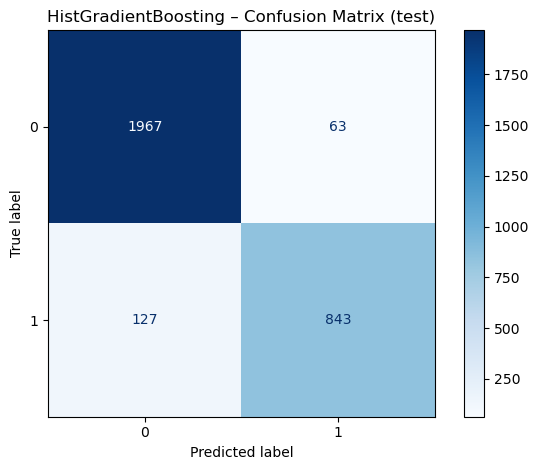

In [19]:
# Confusion Matrix
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'{best_label} – Confusion Matrix (test)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

<Figure size 700x600 with 0 Axes>

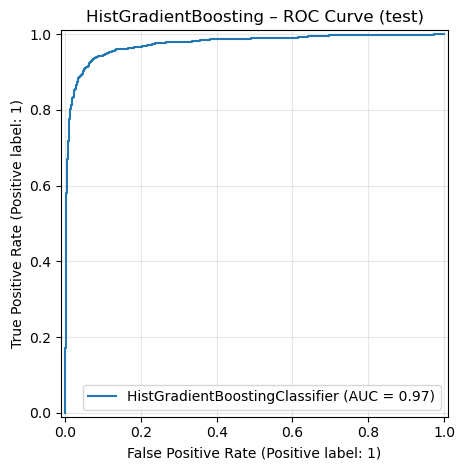

In [20]:
# ROC-кривая
if hasattr(best_model, "predict_proba"):
    plt.figure(figsize=(7, 6))
    RocCurveDisplay.from_estimator(best_model, X_test, y_test)
    plt.title(f'{best_label} – ROC Curve (test)')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "roc_curve.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("ROC: модель не поддерживает predict_proba")

## 7. Интерпретация: Permutation Importance

Permutation importance отвечает на вопрос: "Если случайно перемешать один признак, насколько сильно ухудшится качество модели?"

Если качество падает сильно – признак важен. Если почти не меняется – признак малозначим.

**Ограничения метода:**
- При сильной корреляции признаков важность "размазывается"
- Результат зависит от выбранной метрики
- Из-за случайности стоит делать несколько повторов (`n_repeats`)

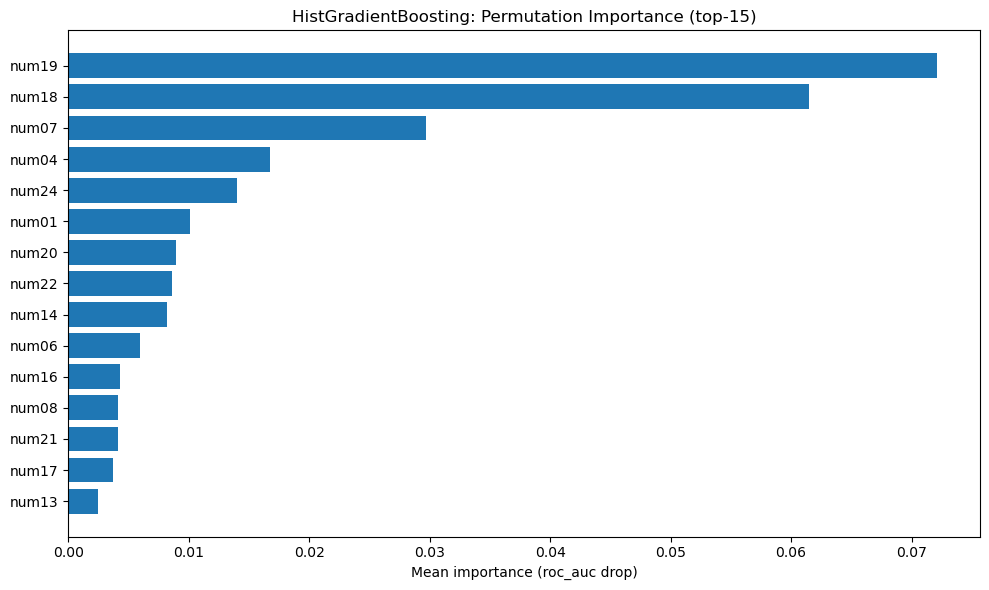

Top-15 важных признаков:
 1. num19                (importance = 0.072084)
 2. num18                (importance = 0.061462)
 3. num07                (importance = 0.029686)
 4. num04                (importance = 0.016726)
 5. num24                (importance = 0.014023)
 6. num01                (importance = 0.010085)
 7. num20                (importance = 0.008898)
 8. num22                (importance = 0.008597)
 9. num14                (importance = 0.008189)
10. num06                (importance = 0.005901)
11. num16                (importance = 0.004243)
12. num08                (importance = 0.004147)
13. num21                (importance = 0.004136)
14. num17                (importance = 0.003726)
15. num13                (importance = 0.002493)


In [21]:
# Permutation importance на тесте (top-15)
scoring = "roc_auc" if hasattr(best_model, "predict_proba") else "accuracy"

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring=scoring,
    n_jobs=-1
)

imp = perm.importances_mean
idx = np.argsort(imp)[::-1][:15]

plt.figure(figsize=(10, 6))
plt.barh(range(len(idx)), imp[idx][::-1])
plt.yticks(range(len(idx)), [X.columns[i] for i in idx[::-1]])
plt.xlabel(f"Mean importance ({scoring} drop)")
plt.title(f"{best_label}: Permutation Importance (top-15)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "permutation_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# Вывод top-15 признаков
print("Top-15 важных признаков:")
for i, feat_idx in enumerate(idx, 1):
    print(f"{i:2d}. {X.columns[feat_idx]:20s} (importance = {imp[feat_idx]:.6f})")

## 8. Сохранение лучшей модели

Сохраняем лучшую модель в `artifacts/best_model.joblib` и метаданные в `best_model_meta.json`.

In [22]:
# Сохранение лучшей модели и метаданных
model_path = ARTIFACTS_DIR / "best_model.joblib"
joblib.dump(best_model, model_path)

meta = {
    "best_model_label": best_label,
    "test_metrics": best_row.to_dict(),
    "search_summary": search_summaries.get(best_label, None),
    "random_state": RANDOM_STATE,
    "dataset": "S06-hw-dataset-01.csv",
    "train_size": len(X_train),
    "test_size": len(X_test),
}
save_json(meta, ARTIFACTS_DIR / "best_model_meta.json")

print("Saved:", model_path)
print("Saved:", ARTIFACTS_DIR / "best_model_meta.json")
print("\nМетаданные:")
print(json.dumps(meta, indent=2, ensure_ascii=False))

Saved: artifacts\best_model.joblib
Saved: artifacts\best_model_meta.json

Метаданные:
{
  "best_model_label": "HistGradientBoosting",
  "test_metrics": {
    "accuracy": 0.9366666666666666,
    "f1": 0.8987206823027718,
    "roc_auc": 0.9742181707379005,
    "model": "HistGradientBoosting"
  },
  "search_summary": {
    "best_params": {
      "learning_rate": 0.05,
      "max_depth": null,
      "max_leaf_nodes": 63
    },
    "best_cv_roc_auc": 0.9721417717189265
  },
  "random_state": 42,
  "dataset": "S06-hw-dataset-01.csv",
  "train_size": 9000,
  "test_size": 3000
}


## 9. Итоги

- Сравнили baseline'ы и модели недели 6 в **едином и честном протоколе**
- Подбор гиперпараметров делали через CV **только на train**
- Тест использовали один раз – для финальной оценки, без "дотюнинга" по тесту
- Артефакты эксперимента сохранены в `artifacts/`: метрики, параметры подбора, лучшая модель и метаданные
- Проведена интерпретация лучшей модели через permutation importance